
# 🛡️ SafeShield AI — Phishing & Scam Threat Detector
### HackNowa Global Hackathon 2026 | Digital Safety & Cybersecurity

SafeShield AI is a defensive cybersecurity prototype that analyzes suspicious messages and URLs without opening or interacting with the destination.

**Pipeline:** Input → NLP classifier → URL lexical analysis → Explainable risk fusion → Safety recommendation

> Never paste passwords, OTPs, API keys, card numbers, or other secrets into this notebook.



## 1. Problem and solution

Phishing and social-engineering messages commonly use urgency, impersonation, fake rewards, payment requests, credential requests, and suspicious links.

SafeShield AI combines:
- TF-IDF + Logistic Regression for message classification
- Safe URL lexical analysis without network requests
- Transparent security heuristics
- A 0–100 risk score
- Explainable reasons and safer next actions

The prototype uses a synthetic dataset so the project is reproducible and privacy-safe.


In [ ]:

# 2. Setup
# If needed, uncomment:
# %pip install pandas numpy scikit-learn matplotlib joblib streamlit

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from urllib.parse import urlparse

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

np.random.seed(42)
print("SafeShield AI environment ready.")


SafeShield AI environment ready.


In [ ]:

# 3. Build a reproducible synthetic training dataset

legitimate = [
    "Your monthly electricity bill is ready in the official customer portal.",
    "Your bank statement is available in your banking app.",
    "Your package is scheduled for delivery tomorrow.",
    "Your meeting is confirmed for 3 PM today.",
    "Your password was changed successfully from the security settings.",
    "Your subscription renewal is scheduled for next month.",
    "Your college payment receipt is available in the student portal.",
    "Your order has been shipped and can be tracked from the official app.",
    "Your appointment is confirmed for Monday at 10 AM.",
    "Your monthly report is ready for review.",
    "The support team has received your ticket and will respond shortly.",
    "Your account settings were updated successfully.",
    "Your travel booking confirmation is available in the app.",
    "The invoice for your recent purchase is available in your account.",
    "Your delivery address update has been saved successfully.",
    "Your software update is ready in the official application.",
    "Your scheduled payment was processed successfully.",
    "Your course enrollment has been confirmed.",
    "Your interview is scheduled for tomorrow afternoon.",
    "Your account login from a new device was recorded."
]

phishing = [
    "URGENT! Your bank account will be blocked today. Verify your password immediately at http://secure-account.example",
    "Congratulations! You won a cash prize. Claim now by entering your card details.",
    "Your parcel is on hold. Pay a small delivery fee immediately using the attached link.",
    "Security alert! Your account will be suspended unless you confirm your login credentials now.",
    "You have received a reward. Send your OTP to complete the verification.",
    "FINAL WARNING: unusual activity detected. Confirm your username and password immediately.",
    "Your payment failed. Update your card details now to avoid account cancellation.",
    "You are selected for a special offer. Click the link and provide your banking information.",
    "Your tax refund is waiting. Enter your bank information to receive the refund today.",
    "Your email storage is full. Sign in through this link to prevent account deletion.",
    "Immediate action required: verify your identity with your password and one-time code.",
    "Your mobile number won a lottery. Pay the processing fee to claim the prize.",
    "Your account has been compromised. Send your verification code to our support agent now.",
    "Delivery failed. Confirm your address and pay the outstanding fee through the link.",
    "Your subscription will be cancelled today. Re-enter your payment information immediately.",
    "Click here to unlock your account before it is permanently disabled.",
    "You have an unpaid invoice. Open the link and enter your corporate login credentials.",
    "Important security notice: verify your password now to keep access.",
    "Exclusive reward available today only. Provide your card number to receive it.",
    "Your account has been selected for verification. Share your OTP to continue."
]

df = pd.DataFrame(
    [{"text": x, "label": 0, "category": "legitimate"} for x in legitimate] +
    [{"text": x, "label": 1, "category": "phishing"} for x in phishing]
).sample(frac=1, random_state=42).reset_index(drop=True)

display(df.head())
print("Shape:", df.shape)
display(df["category"].value_counts())


,text,label,category
0,Your account login from a new device was recor...,0,legitimate
1,Your scheduled payment was processed successfu...,0,legitimate
2,Your software update is ready in the official ...,0,legitimate
3,Your payment failed. Update your card details ...,1,phishing
4,Your password was changed successfully from th...,0,legitimate


Shape: (40, 3)


category
legitimate    20
phishing      20
Name: count, dtype: int64

In [ ]:

# 4. Train the NLP detector

X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"],
    test_size=0.25,
    random_state=42,
    stratify=df["label"]
)

text_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True, ngram_range=(1, 2), sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=42
    ))
])

text_model.fit(X_train, y_train)

pred = text_model.predict(X_test)
prob = text_model.predict_proba(X_test)[:, 1]

metrics = pd.Series({
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred, zero_division=0),
    "Recall": recall_score(y_test, pred, zero_division=0),
    "F1": f1_score(y_test, pred, zero_division=0)
})

display(metrics.round(3))
print(classification_report(
    y_test, pred,
    target_names=["Legitimate", "Phishing/Scam"],
    zero_division=0
))


Accuracy     0.900
Precision    1.000
Recall       0.800
F1           0.889
dtype: float64

               precision    recall  f1-score   support

   Legitimate       0.83      1.00      0.91         5
Phishing/Scam       1.00      0.80      0.89         5

     accuracy                           0.90        10
    macro avg       0.92      0.90      0.90        10
 weighted avg       0.92      0.90      0.90        10



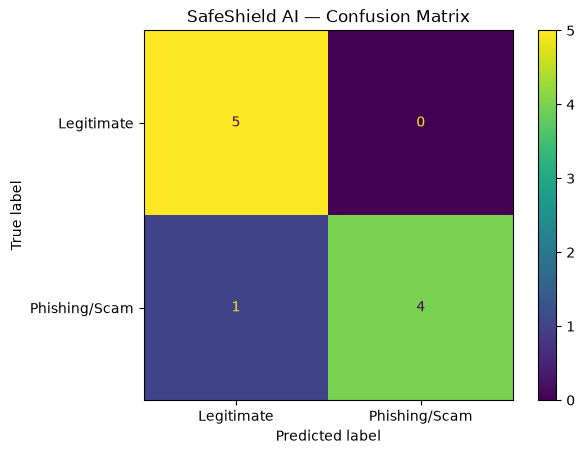

In [ ]:

# 5. Confusion matrix

cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Phishing/Scam"]
).plot()
plt.title("SafeShield AI — Confusion Matrix")
plt.show()



## 2. Safe URL lexical analyzer

The URL analyzer **does not visit the URL**. It only inspects the supplied string.

Indicators include HTTPS usage, IP-based hosts, URL length, subdomains, encoded characters, `@`, ports, username components, suspicious keywords, and common shortener domains.

These are risk indicators, not proof of maliciousness.


In [ ]:

# 6. URL feature extraction and risk scoring

SUSPICIOUS_URL_KEYWORDS = {
    "login", "verify", "verification", "secure", "account",
    "update", "password", "wallet", "bonus", "claim",
    "free", "reward", "urgent", "confirm", "payment"
}
SHORTENER_DOMAINS = {"bit.ly", "tinyurl.com", "t.co", "goo.gl", "is.gd", "ow.ly"}

def url_features(url):
    url = str(url).strip()
    candidate = url if re.match(r"^[a-zA-Z][a-zA-Z0-9+.-]*://", url) else "http://" + url
    parsed = urlparse(candidate)
    hostname = (parsed.hostname or "").lower()
    path_query = ((parsed.path or "") + "?" + (parsed.query or "")).lower()

    return {
        "length": len(url),
        "uses_https": candidate.lower().startswith("https://"),
        "has_ip_host": bool(re.fullmatch(r"(\d{1,3}\.){3}\d{1,3}", hostname)),
        "subdomain_count": max(0, len(hostname.split(".")) - 2),
        "at_symbol": "@" in url,
        "encoded_chars": len(re.findall(r"%[0-9a-fA-F]{2}", url)),
        "double_slash_path": "//" in (parsed.path or ""),
        "has_port": parsed.port is not None if parsed.hostname else False,
        "has_username": parsed.username is not None,
        "suspicious_keywords": [
            w for w in SUSPICIOUS_URL_KEYWORDS if w in path_query or w in hostname
        ],
        "is_shortener": hostname in SHORTENER_DOMAINS
    }

def url_risk_score(url):
    f = url_features(url)
    score, reasons = 0, []

    rules = [
        (not f["uses_https"], 12, "The URL does not use HTTPS."),
        (f["has_ip_host"], 25, "The hostname is an IP address."),
        (f["length"] > 100, 15, "The URL is unusually long."),
        (f["subdomain_count"] >= 3, 12, "The URL contains many subdomain levels."),
        (f["at_symbol"], 18, "The URL contains '@', which can obscure the destination."),
        (f["encoded_chars"] >= 3, 8, "The URL contains multiple encoded characters."),
        (f["double_slash_path"], 8, "The path contains a double-slash pattern."),
        (f["has_port"], 8, "The URL specifies a port."),
        (f["has_username"], 12, "The URL contains a username component."),
        (len(f["suspicious_keywords"]) >= 2, 15, "Multiple security-sensitive keywords appear in the URL."),
        (f["is_shortener"], 10, "The URL uses a shortening service.")
    ]

    for condition, weight, reason in rules:
        if condition:
            score += weight
            reasons.append(reason)

    return min(score, 100), f, reasons

for u in [
    "https://www.example.com/account",
    "http://192.0.2.10/verify/login",
    "http://bit.ly/claim-reward"
]:
    score, features, reasons = url_risk_score(u)
    print(f"\n{u}\nRisk: {score}/100")
    for r in reasons:
        print(" -", r)



https://www.example.com/account
Risk: 0/100

http://192.0.2.10/verify/login
Risk: 52/100
 - The URL does not use HTTPS.
 - The hostname is an IP address.
 - Multiple security-sensitive keywords appear in the URL.

http://bit.ly/claim-reward
Risk: 37/100
 - The URL does not use HTTPS.
 - Multiple security-sensitive keywords appear in the URL.
 - The URL uses a shortening service.


In [ ]:

# 7. Message heuristics and explainable risk fusion

MESSAGE_PATTERNS = {
    "urgency": [r"urgent", r"immediately", r"now", r"final warning", r"today"],
    "credential_request": [r"password", r"login credentials", r"username"],
    "otp_request": [r"otp", r"one[- ]time code", r"verification code"],
    "payment_request": [r"card details", r"card number", r"payment", r"processing fee", r"bank information"],
    "reward_or_prize": [r"won", r"prize", r"reward", r"lottery", r"claim"],
    "account_threat": [r"blocked", r"suspended", r"disabled", r"cancelled", r"deleted"],
    "link": [r"https?://", r"click here", r"link"]
}

HEURISTIC_WEIGHTS = {
    "urgency": 10, "credential_request": 20, "otp_request": 25,
    "payment_request": 20, "reward_or_prize": 15,
    "account_threat": 15, "link": 8
}

def message_heuristics(text):
    text_l = str(text).lower()
    matched, score, reasons = {}, 0, []

    for category, patterns in MESSAGE_PATTERNS.items():
        hits = [p for p in patterns if re.search(p, text_l)]
        if hits:
            matched[category] = hits
            score += HEURISTIC_WEIGHTS[category]
            reasons.append(category.replace("_", " ").title() + " language detected.")

    return min(score, 100), matched, reasons

def extract_urls(text):
    return re.findall(r"https?://[^\s]+", str(text))

def analyze_input(text):
    text = str(text).strip()
    ml_probability = float(text_model.predict_proba([text])[0, 1])
    ml_score = ml_probability * 100

    msg_score, matched, msg_reasons = message_heuristics(text)
    urls = extract_urls(text)
    url_results = []

    for url in urls:
        score, features, reasons = url_risk_score(url)
        url_results.append({
            "url": url, "score": score,
            "features": features, "reasons": reasons
        })

    max_url_score = max([x["score"] for x in url_results], default=0)

    final_score = (
        0.55 * ml_score + 0.20 * msg_score + 0.25 * max_url_score
        if urls else
        0.70 * ml_score + 0.30 * msg_score
    )
    final_score = round(float(min(max(final_score, 0), 100)), 1)

    if final_score >= 60:
        level = "HIGH RISK"
        action = "Do not click links or provide passwords, OTPs, card details, or other sensitive information. Verify independently."
    elif final_score >= 30:
        level = "SUSPICIOUS"
        action = "Pause and verify the sender and request through an official app, website, or known contact."
    else:
        level = "LOW RISK"
        action = "No strong phishing indicators were detected. Still verify unexpected requests before sharing sensitive information."

    reasons = list(msg_reasons)
    for item in url_results:
        reasons.extend(item["reasons"])

    if ml_probability >= 0.65:
        reasons.append("The NLP model found the message similar to phishing/scam examples.")
    elif ml_probability <= 0.35:
        reasons.append("The NLP model found the message more similar to legitimate examples.")

    return {
        "risk_score": final_score,
        "risk_level": level,
        "ml_probability": round(ml_probability, 3),
        "message_heuristic_score": msg_score,
        "urls_found": urls,
        "url_results": url_results,
        "reasons": list(dict.fromkeys(reasons)),
        "recommendation": action
    }

def pretty_report(text):
    result = analyze_input(text)
    print("=" * 70)
    print("🛡️ SAFESHIELD AI THREAT ANALYSIS")
    print("=" * 70)
    print("Input:", text)
    print(f"\nRisk Score: {result['risk_score']}/100")
    print("Risk Level:", result["risk_level"])
    print(f"ML phishing probability: {result['ml_probability']:.1%}")
    print("Message heuristic score:", result["message_heuristic_score"])

    if result["urls_found"]:
        print("\nURL analysis:")
        for item in result["url_results"]:
            print(f"  {item['url']} -> {item['score']}/100")

    print("\nWhy?")
    for reason in result["reasons"]:
        print(" -", reason)

    print("\nRecommended action:")
    print(result["recommendation"])
    return result


In [ ]:

# 8. End-to-end defensive tests

test_cases = [
    "Your meeting is confirmed for 3 PM today.",
    "URGENT! Your bank account will be blocked today. Verify your password immediately at http://secure-account.example",
    "Congratulations! You won a reward. Send your OTP to claim it.",
    "Your order has been shipped and can be tracked from the official app.",
    "Your parcel is on hold. Pay a delivery fee at http://192.0.2.10/verify"
]

for text in test_cases:
    r = analyze_input(text)
    print(f"{r['risk_level']:12} | {r['risk_score']:5.1f} | {text}")


LOW RISK     |  29.7 | Your meeting is confirmed for 3 PM today.
SUSPICIOUS   |  47.5 | URGENT! Your bank account will be blocked today. Verify your password immediately at http://secure-account.example
SUSPICIOUS   |  57.1 | Congratulations! You won a reward. Send your OTP to claim it.
LOW RISK     |  26.7 | Your order has been shipped and can be tracked from the official app.
SUSPICIOUS   |  40.8 | Your parcel is on hold. Pay a delivery fee at http://192.0.2.10/verify


In [ ]:

# 9. Interactive analyst demo
# Replace sample_input with your own non-sensitive test message.

sample_input = "URGENT! Your account will be suspended. Verify your password immediately at http://secure-account.example/login"
pretty_report(sample_input)


🛡️ SAFESHIELD AI THREAT ANALYSIS
Input: URGENT! Your account will be suspended. Verify your password immediately at http://secure-account.example/login

Risk Score: 48.5/100
Risk Level: SUSPICIOUS
ML phishing probability: 56.6%
Message heuristic score: 53

URL analysis:
  http://secure-account.example/login -> 27/100

Why?
 - Urgency language detected.
 - Credential Request language detected.
 - Account Threat language detected.
 - Link language detected.
 - The URL does not use HTTPS.
 - Multiple security-sensitive keywords appear in the URL.

Recommended action:
Pause and verify the sender and request through an official app, website, or known contact.


{'risk_score': 48.5,
 'risk_level': 'SUSPICIOUS',
 'ml_probability': 0.566,
 'message_heuristic_score': 53,
 'urls_found': ['http://secure-account.example/login'],
 'url_results': [{'url': 'http://secure-account.example/login',
   'score': 27,
   'features': {'length': 35,
    'uses_https': False,
    'has_ip_host': False,
    'subdomain_count': 0,
    'at_symbol': False,
    'encoded_chars': 0,
    'double_slash_path': False,
    'has_port': False,
    'has_username': False,
    'suspicious_keywords': ['account', 'login', 'secure'],
    'is_shortener': False},
   'reasons': ['The URL does not use HTTPS.',
    'Multiple security-sensitive keywords appear in the URL.']}],
 'reasons': ['Urgency language detected.',
  'Credential Request language detected.',
  'Account Threat language detected.',
  'Link language detected.',
  'The URL does not use HTTPS.',
  'Multiple security-sensitive keywords appear in the URL.'],
 'recommendation': 'Pause and verify the sender and request through an 

In [ ]:

# 10. ML explainability: influential vocabulary

vectorizer = text_model.named_steps["tfidf"]
classifier = text_model.named_steps["clf"]
feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = classifier.coef_[0]

print("Terms most associated with the phishing class:")
print(", ".join(feature_names[np.argsort(coefficients)[-20:]][::-1]))

print("\nTerms most associated with the legitimate class:")
print(", ".join(feature_names[np.argsort(coefficients)[:20]]))


Terms most associated with the phishing class:
to, you, link, verification, immediately, account, information, enter your, enter, now, your account, otp, otp to, your otp, account has, selected, selected for, it, reward, click

Terms most associated with the legitimate class:
confirmed, scheduled, was, successfully, is, available in, is available, from, in the, app, in, is scheduled, scheduled for, is confirmed, confirmed for, update, for, from the, available, the official


In [ ]:

# 11. Batch-analysis workflow for a small business

def analyze_dataframe(input_df, text_column="text"):
    rows = []
    for _, row in input_df.iterrows():
        r = analyze_input(row[text_column])
        rows.append({
            "risk_score": r["risk_score"],
            "risk_level": r["risk_level"],
            "ml_probability": r["ml_probability"],
            "recommendation": r["recommendation"]
        })
    return pd.concat([input_df.reset_index(drop=True), pd.DataFrame(rows)], axis=1)

demo_batch = pd.DataFrame({
    "message_id": [1, 2, 3, 4],
    "text": [
        "Your meeting is confirmed for 3 PM.",
        "URGENT! Verify your password now at http://secure-account.example",
        "Your order has been shipped.",
        "Congratulations! Send your OTP to claim your reward."
    ]
})

display(analyze_dataframe(demo_batch))


,message_id,text,risk_score,risk_level,ml_probability,recommendation
0,1,Your meeting is confirmed for 3 PM.,26.2,LOW RISK,0.374,No strong phishing indicators were detected. S...
1,2,URGENT! Verify your password now at http://sec...,42.5,SUSPICIOUS,0.511,Pause and verify the sender and request throug...
2,3,Your order has been shipped.,30.3,SUSPICIOUS,0.432,Pause and verify the sender and request throug...
3,4,Congratulations! Send your OTP to claim your r...,55.4,SUSPICIOUS,0.620,Pause and verify the sender and request throug...


In [ ]:

# 12. Save the trained model for the web application

import joblib
joblib.dump(text_model, "safeshield_text_model.joblib")
print("Saved: safeshield_text_model.joblib")


Saved: safeshield_text_model.joblib



## 3. Streamlit application

Create `app.py` using the architecture below. The application should:
1. accept a message/URL as text,
2. classify it,
3. display risk score and reasons,
4. never fetch the submitted URL.

Run:

```bash
pip install pandas numpy scikit-learn joblib streamlit
streamlit run app.py
```


In [ ]:

# 13. Generate app.py automatically

app_code = r'''
import re
import joblib
import streamlit as st
from urllib.parse import urlparse

model = joblib.load("safeshield_text_model.joblib")

KEYWORDS = {"login","verify","secure","account","password","claim","reward","urgent","confirm","payment"}
SHORTENERS = {"bit.ly","tinyurl.com","t.co","goo.gl","is.gd","ow.ly"}

def url_risk(url):
    candidate = url if re.match(r"^[a-zA-Z][a-zA-Z0-9+.-]*://", url) else "http://" + url
    p = urlparse(candidate)
    host = (p.hostname or "").lower()
    path = ((p.path or "") + "?" + (p.query or "")).lower()
    score, reasons = 0, []

    checks = [
        (not candidate.lower().startswith("https://"), 12, "No HTTPS"),
        (bool(re.fullmatch(r"(\d{1,3}\.){3}\d{1,3}", host)), 25, "IP address hostname"),
        (len(url) > 100, 15, "Unusually long URL"),
        (len(host.split(".")) >= 5, 12, "Many subdomain levels"),
        ("@" in url, 18, "Contains @"),
        (len(re.findall(r"%[0-9a-fA-F]{2}", url)) >= 3, 8, "Multiple encoded characters"),
        (host in SHORTENERS, 10, "URL shortener")
    ]
    for condition, weight, reason in checks:
        if condition:
            score += weight
            reasons.append(reason)

    if sum(k in host + path for k in KEYWORDS) >= 2:
        score += 15
        reasons.append("Multiple security-sensitive keywords")

    return min(score, 100), reasons

st.set_page_config(page_title="SafeShield AI", page_icon="🛡️")
st.title("🛡️ SafeShield AI")
st.subheader("Phishing & Scam Threat Detector")
st.caption("Defensive analysis only. Submitted URLs are never opened.")

text = st.text_area(
    "Paste a suspicious message or URL",
    height=180,
    placeholder="Example: URGENT! Verify your account immediately..."
)

if st.button("Analyze", type="primary") and text.strip():
    ml_probability = float(model.predict_proba([text])[0, 1])
    ml_score = ml_probability * 100

    urls = re.findall(r"https?://[^\s]+", text)
    max_url_score = 0
    reasons = []

    for url in urls:
        s, rs = url_risk(url)
        max_url_score = max(max_url_score, s)
        reasons.extend(rs)

    final_score = 0.75 * ml_score + 0.25 * max_url_score if urls else ml_score

    if final_score >= 60:
        level = "🔴 HIGH RISK"
    elif final_score >= 30:
        level = "🟠 SUSPICIOUS"
    else:
        level = "🟢 LOW RISK"

    st.metric("Risk Score", f"{final_score:.1f}/100")
    st.markdown(f"## {level}")
    st.write(f"Model phishing probability: **{ml_probability:.1%}**")

    if reasons:
        st.markdown("### URL indicators")
        for reason in sorted(set(reasons)):
            st.write("• " + reason)

    st.info(
        "Do not provide passwords, OTPs, payment details, or other sensitive "
        "information based solely on an unexpected message. Verify independently."
    )
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("Created app.py")


Created app.py



## 4. GitHub structure

```text
SafeShield-AI/
├── SafeShield_AI_Cybersecurity_Hackathon.ipynb
├── app.py
├── safeshield_text_model.joblib
├── requirements.txt
├── README.md
├── .gitignore
├── data/
├── models/
├── screenshots/
└── demo/
```

### requirements.txt

```text
pandas
numpy
scikit-learn
matplotlib
joblib
streamlit
```



## 5. Hackathon demo plan — 3 minutes

**0:00–0:20 — Problem:** Explain phishing, social engineering, urgency, credential theft, and malicious links.

**0:20–0:40 — Solution:** Introduce SafeShield AI and its three layers: NLP, URL analysis, explainable risk fusion.

**0:40–1:30 — Live demo:** Show a legitimate message, then a suspicious message with a safe example URL. Demonstrate the score, reasons, and recommendation.

**1:30–2:10 — Technical:** Explain TF-IDF, Logistic Regression, lexical URL features, and risk fusion.

**2:10–2:40 — Impact:** Individuals and small businesses can use it as a decision-support layer before interacting with suspicious content.

**2:40–3:00 — Future scope:** multilingual detection, calibrated production datasets, browser/email integration, enterprise threat intelligence, privacy-preserving inference.



# 6. Responsible-use and limitations

This is a **prototype defensive cybersecurity tool**, not a replacement for antivirus, secure email gateways, browser protections, or professional security operations.

The synthetic dataset is intentionally small and should not be used to claim production-level detection performance.

For a stronger final submission:
- use a properly licensed and representative phishing dataset,
- validate on unseen data,
- report false positives and false negatives,
- calibrate thresholds,
- test multiple languages and attack patterns,
- protect privacy,
- never collect passwords, OTPs, API keys, or payment credentials,
- keep threat intelligence and models updated.

### Final project pitch

**SafeShield AI — Explainable AI-powered phishing and scam detection that helps users pause, understand risk, and verify suspicious digital communication before sharing sensitive information.**
